In [1]:
# BIG DATA UTS #

In [2]:
import sys
!{sys.executable} -m pip install requests


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import requests

url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_day.geojson"

response = requests.get(url)

data = response.json()

print("Jumlah gempa:", len(data["features"]))

Jumlah gempa: 232


In [4]:
import requests
import pandas as pd

url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_day.geojson"

response = requests.get(url)
data = response.json()

rows = []

for gempa in data["features"]:
    rows.append({
        "waktu": gempa["properties"]["time"],
        "lokasi": gempa["properties"]["place"],
        "magnitudo": gempa["properties"]["mag"],
        "kedalaman": gempa["geometry"]["coordinates"][2],
        "latitude": gempa["geometry"]["coordinates"][1],
        "longitude": gempa["geometry"]["coordinates"][0]
    })

df = pd.DataFrame(rows)

df.head()

,waktu,lokasi,magnitudo,kedalaman,latitude,longitude
0,1790820623107,"49 km ENE of Pedro Bay, Alaska",2.20,128.90,59.879000,-153.249000
1,1790820184150,"12 km NNW of Wai‘ōhinu, Hawaii",1.80,5.53,19.176167,-155.664169
2,1790819882030,"10 km WNW of The Geysers, CA",1.18,2.79,38.820835,-122.852669
3,1790819819800,"10 km WNW of The Geysers, CA",0.75,2.56,38.821499,-122.852501
4,1790819583650,"8 km ESE of Valle Vista, CA",0.95,15.44,33.708167,-116.819833


In [5]:
df["waktu"] = pd.to_datetime(df["waktu"])

df = df.sort_values("waktu").reset_index(drop=True)

df.head()

,waktu,lokasi,magnitudo,kedalaman,latitude,longitude
0,1970-01-01 00:29:50.735242678,"70 km SE of Kokhanok, Alaska",2.40,13.700000,58.986000,-153.927000
1,1970-01-01 00:29:50.735444716,"104 km SSE of Sarangani, Philippines",4.50,156.847000,4.502100,125.747200
2,1970-01-01 00:29:50.735568779,"47 km SSW of Manley Hot Springs, Alaska",1.50,17.500000,64.622000,-151.087000
3,1970-01-01 00:29:50.735750369,"112 km SSW of Banda Aceh, Indonesia",4.50,33.873000,4.648800,94.851500
4,1970-01-01 00:29:50.735969600,"4 km SSW of Pāhala, Hawaii",1.74,28.469999,19.162001,-155.494507


In [7]:
df["rolling_magnitudo"] = df["magnitudo"].rolling(window=5).mean()

df[["waktu", "magnitudo", "rolling_magnitudo"]].head(10)

,waktu,magnitudo,rolling_magnitudo
0,1970-01-01 00:29:50.735242678,2.400000,NaN
1,1970-01-01 00:29:50.735444716,4.500000,NaN
2,1970-01-01 00:29:50.735568779,1.500000,NaN
3,1970-01-01 00:29:50.735750369,4.500000,NaN
4,1970-01-01 00:29:50.735969600,1.740000,2.928000
5,1970-01-01 00:29:50.736134830,0.430000,2.534000
6,1970-01-01 00:29:50.736399870,-0.510000,1.532000
7,1970-01-01 00:29:50.737227210,3.810087,1.994017
8,1970-01-01 00:29:50.737545450,-1.130000,0.868017
9,1970-01-01 00:29:50.738218760,1.920000,0.904017


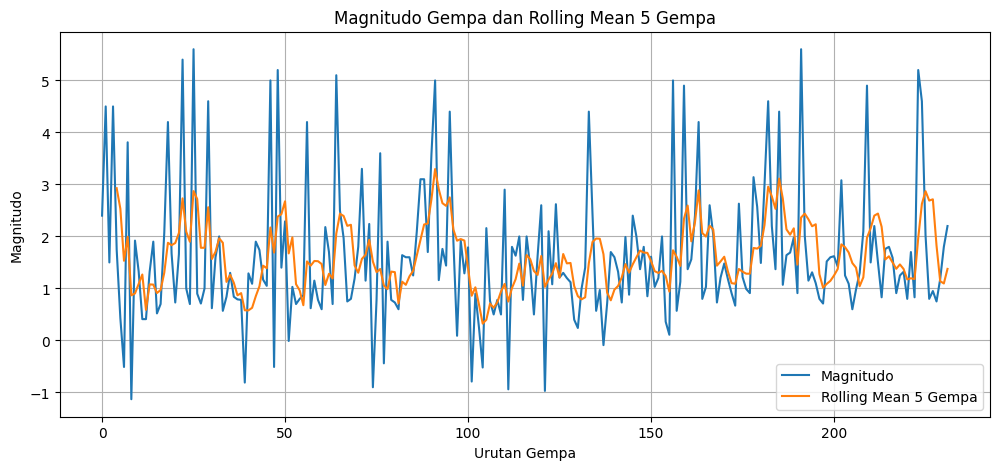

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(df["magnitudo"], label="Magnitudo")
plt.plot(df["rolling_magnitudo"], label="Rolling Mean 5 Gempa")

plt.xlabel("Urutan Gempa")
plt.ylabel("Magnitudo")
plt.title("Magnitudo Gempa dan Rolling Mean 5 Gempa")
plt.legend()
plt.grid()
plt.show()